In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:

results = pd.read_csv("data/results.csv")
scorers = pd.read_csv("data/goalscorers.csv")
shootouts = pd.read_csv("data/shootouts.csv")
former = pd.read_csv("data/former_names.csv")

In [5]:
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49282,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49283,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49284,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49285,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [6]:
scorers

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False
...,...,...,...,...,...,...,...,...
47596,2026-03-31,Sweden,Poland,Sweden,Anthony Elanga,20.0,False,False
47597,2026-03-31,Sweden,Poland,Poland,Nicola Zalewski,33.0,False,False
47598,2026-03-31,Sweden,Poland,Sweden,Gustaf Lagerbielke,44.0,False,False
47599,2026-03-31,Sweden,Poland,Poland,Karol Świderski,55.0,False,False


In [7]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [8]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  str    
 1   home_team   49287 non-null  str    
 2   away_team   49287 non-null  str    
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  str    
 6   city        49287 non-null  str    
 7   country     49287 non-null  str    
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [9]:
results.describe()

,home_score,away_score
count,49215.000000,49215.000000
mean,1.756091,1.182404
std,1.770617,1.401770
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [10]:
results["date"] = pd.to_datetime(results["date"])
scorers["date"] = pd.to_datetime(scorers["date"])


In [11]:
results.isnull().sum()


date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [12]:
results.isnull()


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
49282,False,False,False,True,True,False,False,False,False
49283,False,False,False,True,True,False,False,False,False
49284,False,False,False,True,True,False,False,False,False
49285,False,False,False,True,True,False,False,False,False


In [13]:
results = results.dropna(subset=["home_score", "away_score"])


In [14]:
results.isnull().sum()



date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [16]:
results.describe()

,date,home_score,away_score
count,49215,49215.000000,49215.000000
mean,1994-03-27 17:37:19.000304,1.756091,1.182404
min,1872-11-30 00:00:00,0.000000,0.000000
25%,1980-07-05 12:00:00,1.000000,0.000000
50%,2000-06-11 00:00:00,1.000000,1.000000
75%,2013-06-04 00:00:00,2.000000,2.000000
max,2026-03-31 00:00:00,31.000000,21.000000
std,NaN,1.770617,1.401770


In [18]:
results.info()


<class 'pandas.DataFrame'>
RangeIndex: 49215 entries, 0 to 49214
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49215 non-null  datetime64[us]
 1   home_team   49215 non-null  str           
 2   away_team   49215 non-null  str           
 3   home_score  49215 non-null  float64       
 4   away_score  49215 non-null  float64       
 5   tournament  49215 non-null  str           
 6   city        49215 non-null  str           
 7   country     49215 non-null  str           
 8   neutral     49215 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), str(5)
memory usage: 3.1 MB


In [19]:
results["home_score"] = results["home_score"].astype(int)



In [20]:
results.info()



<class 'pandas.DataFrame'>
RangeIndex: 49215 entries, 0 to 49214
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49215 non-null  datetime64[us]
 1   home_team   49215 non-null  str           
 2   away_team   49215 non-null  str           
 3   home_score  49215 non-null  int64         
 4   away_score  49215 non-null  float64       
 5   tournament  49215 non-null  str           
 6   city        49215 non-null  str           
 7   country     49215 non-null  str           
 8   neutral     49215 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 3.1 MB


In [21]:
results["away_score"] = results["away_score"].astype(int)

In [22]:
results.drop_duplicates(inplace=True)

In [23]:
results.describe()

,date,home_score,away_score
count,49215,49215.000000,49215.000000
mean,1994-03-27 17:37:19.000304,1.756091,1.182404
min,1872-11-30 00:00:00,0.000000,0.000000
25%,1980-07-05 12:00:00,1.000000,0.000000
50%,2000-06-11 00:00:00,1.000000,1.000000
75%,2013-06-04 00:00:00,2.000000,2.000000
max,2026-03-31 00:00:00,31.000000,21.000000
std,NaN,1.770617,1.401770


In [24]:
results["total_goals"] = results["home_score"] + results["away_score"]


In [26]:
results["winner"] = results.apply(
    lambda row: row["home_team"] if row["home_score"] > row["away_score"]
    else ("away_team" if row["away_score"] > row["home_score"] else "Draw"),
    axis=1
)


In [27]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals,winner
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,0,Draw
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,6,England
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,3,Scotland
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,4,Draw
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,3,Scotland


In [28]:
results["year"] = results["date"].dt.year

In [29]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals,winner,year
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,0,Draw,1872
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,6,England,1873
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,3,Scotland,1874
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,4,Draw,1875
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,3,Scotland,1876


In [31]:
results["winner"] = results.apply(
    lambda row: row["home_team"] if row["home_score"] > row["away_score"]
else (row["away_team"] if row["away_score"] > row["home_score"] else "Draw") ,   axis=1
)


In [32]:
results.head()


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals,winner,year
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,0,Draw,1872
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,6,England,1873
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,3,Scotland,1874
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,4,Draw,1875
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,3,Scotland,1876


In [36]:
results[results["winner"]=="Draw"].count()


date           11197
home_team      11197
away_team      11197
home_score     11197
away_score     11197
tournament     11197
city           11197
country        11197
neutral        11197
total_goals    11197
winner         11197
year           11197
dtype: int64

In [37]:
results["total_goals"].mean()
results["total_goals"].median()


np.float64(3.0)

In [38]:
results["total_goals"].mean()


np.float64(2.93849436147516)

In [39]:
results["total_goals"].median()

np.float64(3.0)

In [40]:
results["total_goals"].std()

np.float64(2.092774574055148)

In [41]:
Q1 = results["total_goals"].quantile(0.25)
Q3 = results["total_goals"].quantile(0.75)

IQR = Q3 - Q1

outliers = results[
    (results["total_goals"] < Q1 - 1.5 * IQR) |
    (results["total_goals"] > Q3 + 1.5 * IQR)
]

In [42]:
outliers


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals,winner,year
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,False,9,Scotland,1878
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,False,9,Scotland,1878
11,1879-04-05,England,Scotland,5,4,Friendly,London,England,False,9,England,1879
13,1880-03-13,Scotland,England,5,4,Friendly,Glasgow,Scotland,False,9,Scotland,1880
19,1882-02-18,Northern Ireland,England,0,13,Friendly,Belfast,Ireland,False,13,England,1882
...,...,...,...,...,...,...,...,...,...,...,...,...
48630,2025-09-09,Norway,Moldova,11,1,FIFA World Cup qualification,Oslo,Norway,False,12,Norway,2025
48669,2025-10-09,Austria,San Marino,10,0,FIFA World Cup qualification,Vienna,Austria,False,10,Austria,2025
48801,2025-10-14,Yemen,Brunei,9,0,AFC Asian Cup qualification,Kuwait City,Kuwait,True,9,Yemen,2025
48900,2025-11-16,Portugal,Armenia,9,1,FIFA World Cup qualification,Porto,Portugal,False,10,Portugal,2025


Q1


In [43]:
Q1


np.float64(1.0)

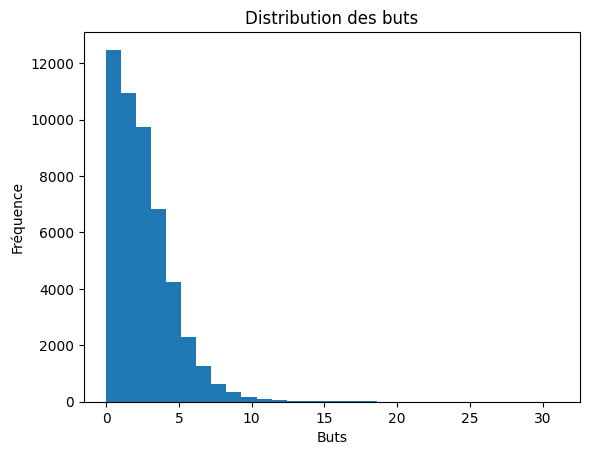

In [44]:
plt.hist(results["total_goals"], bins=30)
plt.title("Distribution des buts")
plt.xlabel("Buts")
plt.ylabel("Fréquence")
plt.show()


In [45]:
results.describe()

,date,home_score,away_score,total_goals,year
count,49215,49215.000000,49215.000000,49215.000000,49215.000000
mean,1994-03-27 17:37:19.000304,1.756091,1.182404,2.938494,1993.705882
min,1872-11-30 00:00:00,0.000000,0.000000,0.000000,1872.000000
25%,1980-07-05 12:00:00,1.000000,0.000000,1.000000,1980.000000
50%,2000-06-11 00:00:00,1.000000,1.000000,3.000000,2000.000000
75%,2013-06-04 00:00:00,2.000000,2.000000,4.000000,2013.000000
max,2026-03-31 00:00:00,31.000000,21.000000,31.000000,2026.000000
std,NaN,1.770617,1.401770,2.092775,25.399325


In [46]:
results.head()


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals,winner,year
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,0,Draw,1872
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,6,England,1873
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,3,Scotland,1874
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,4,Draw,1875
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,3,Scotland,1876


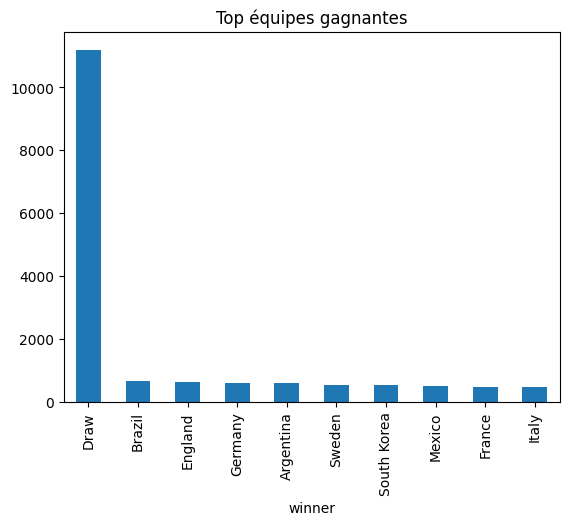

In [47]:
top_teams = results["winner"].value_counts().head(10)

top_teams.plot(kind="bar")
plt.title("Top équipes gagnantes")
plt.show()


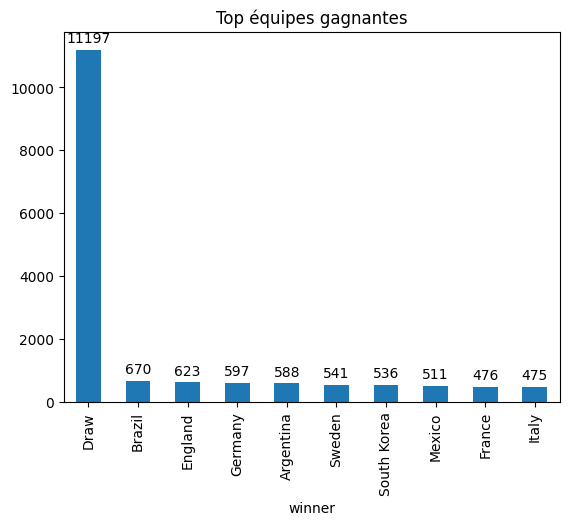

In [53]:
top_teams = results["winner"].value_counts().head(10)

ax=top_teams.plot(kind="bar")
ax.bar_label(ax.containers[0], padding=3)

plt.title("Top équipes gagnantes")
plt.show()

Task was destroyed but it is pending!
task: <Task pending name='Task-269' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/laraibi/projects/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-270' coro=<Kernel.shell_main() running at /Users/laraibi/projects/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/laraibi/projects/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/contextlib.py:136: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def __enter__(self):
Task was destroyed but it is pending!
task: <Task pending name='Task-270' coro=<Kernel.shell_main() running at /Users/laraibi/projects/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


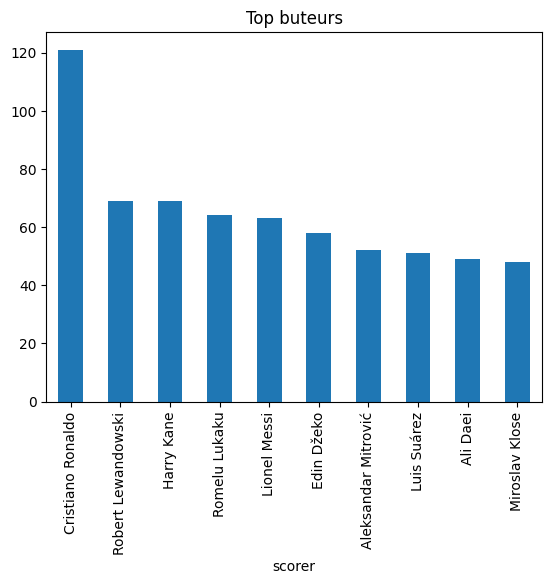

In [54]:
top_scorers = scorers["scorer"].value_counts().head(10)

top_scorers.plot(kind="bar")
plt.title("Top buteurs")
plt.show()

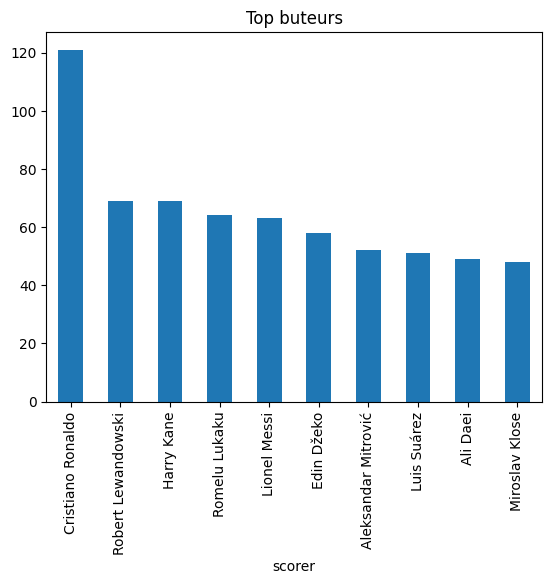

In [55]:
top_scorers = scorers["scorer"].value_counts().head(10)

top_scorers.plot(kind="bar")
plt.title("Top buteurs")
plt.show()


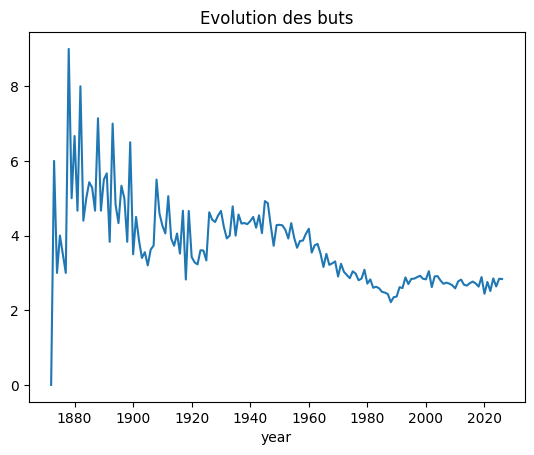

In [56]:
goals_per_year = results.groupby("year")["total_goals"].mean()

goals_per_year.plot()
plt.title("Evolution des buts")
plt.show()

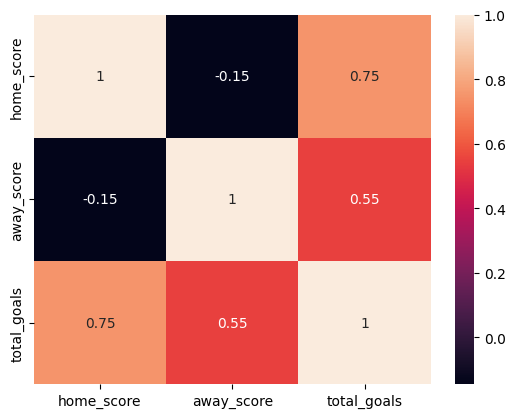

In [57]:
corr = results[["home_score", "away_score", "total_goals"]].corr()

sns.heatmap(corr, annot=True)
plt.show()